In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

file_path = '/content/drive/MyDrive/Disease_symptom_and_patient_profile_dataset.csv'

# 1. Load the data
df = pd.read_csv(file_path)

# 2. THE UPGRADE: Include ALL columns except the final target column
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 3. Convert categorical strings to numbers
x = pd.get_dummies(x, drop_first=True)

# 4. Split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

# NOTE: Tree-based models like Random Forest do NOT need StandardScaler,
# so we completely removed the scaling step to keep the code clean!

# 5.Initialize the Random Forest Model
# n_estimators=100 means the model will build 100 different decision trees and average their results
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 6. Train the model
clf.fit(x_train, y_train)

# 7. Make predictions
y_pred = clf.predict(x_test)

# 8. THE UPGRADE: A detailed evaluation of the results
print("--- MODEL ACCURACY ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

print("--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))

--- MODEL ACCURACY ---
Accuracy Score: 0.8571

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Negative       0.75      0.92      0.83        13
    Positive       0.95      0.82      0.88        22

    accuracy                           0.86        35
   macro avg       0.85      0.87      0.85        35
weighted avg       0.87      0.86      0.86        35

--- CONFUSION MATRIX ---
[[12  1]
 [ 4 18]]


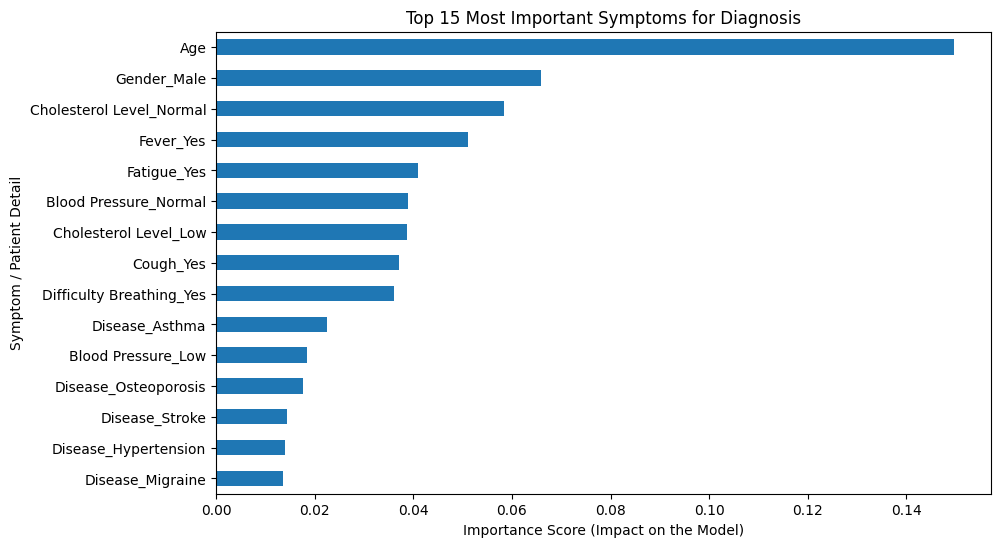

In [7]:
# 1. Extract the feature importance scores from the trained model
importances = clf.feature_importances_

# 2. Get the names of the columns (symptoms) from your 'x' dataframe
feature_names = x.columns

# 3. Create a Pandas Series to pair the scores with the symptom names
feature_importances = pd.Series(importances, index=feature_names)

# 4. Sort them to find the most important ones
# (We will take the top 15 so the chart doesn't get too crowded)
top_features = feature_importances.sort_values(ascending=False).head(15)

# 5. Plot the results as a horizontal bar chart
plt.figure(figsize=(10, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Most Important Symptoms for Diagnosis')
plt.xlabel('Importance Score (Impact on the Model)')
plt.ylabel('Symptom / Patient Detail')

# This flips the y-axis so the most important feature is at the very top
plt.gca().invert_yaxis()
plt.show()